In [73]:
import pandas as pd

url = "https://raw.githubusercontent.com/Asif117204/220-128_Asif_K-Means/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(url)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [74]:
df.shape

(200, 5)

In [75]:
df.drop(['CustomerID','Gender'], axis=1, inplace=True)

In [76]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [77]:
#df = df.rename(columns={'Age': 'age', 'Annual Income (k$)':'income', 'Spending Score (1-100)':'score'})
df.rename(columns={'Age': 'age', 'Annual Income (k$)':'income', 'Spending Score (1-100)':'score'}, inplace=True)

In [78]:
df.head()

,age,income,score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [79]:
df.shape

(200, 3)

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as wr
wr.filterwarnings('ignore')

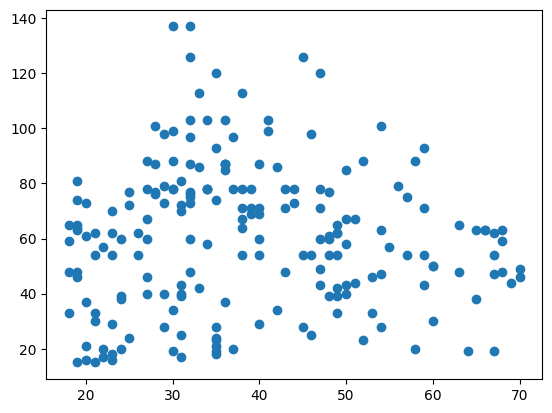

In [81]:
plt.scatter(df.age, df.income)
plt.show()

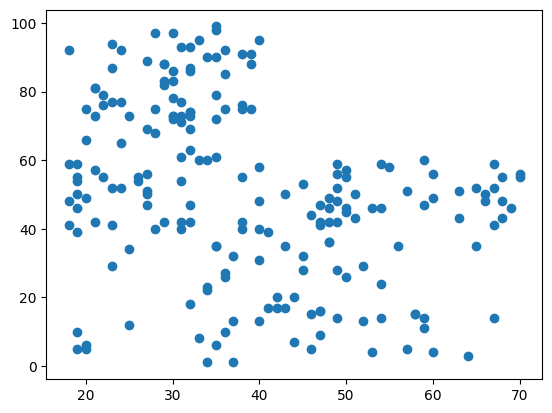

In [82]:
plt.scatter(df.age, df.score)
plt.show()

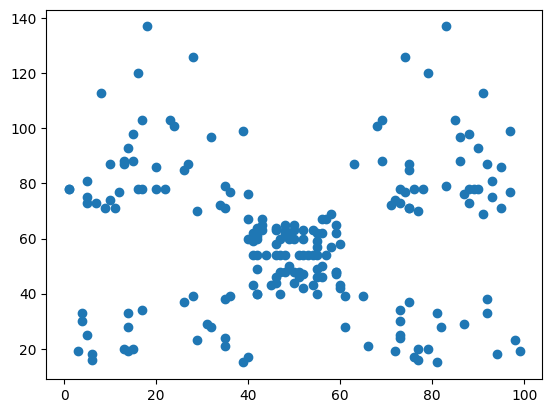

In [83]:
plt.scatter(df.score, df.income)
plt.show()

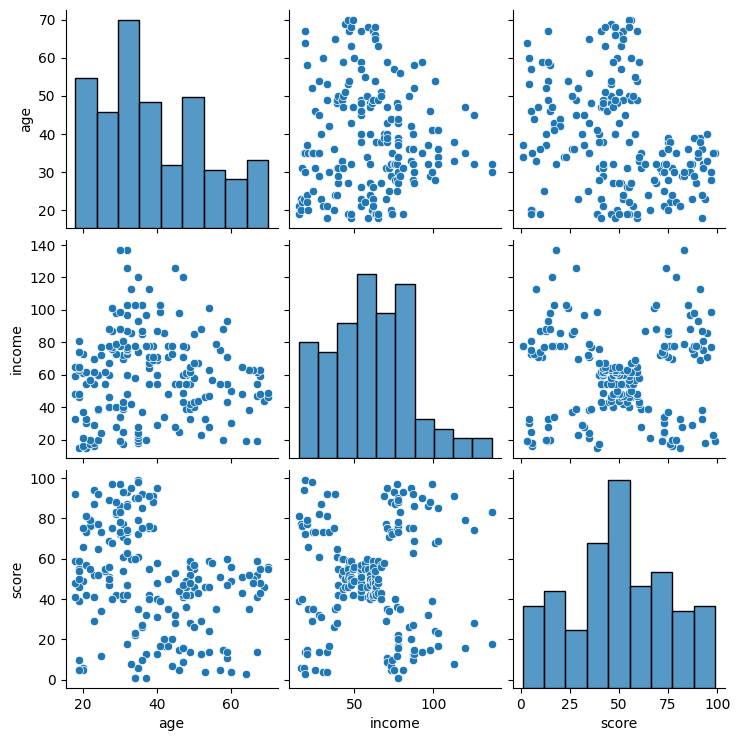

In [84]:
sns.pairplot(df[['age','income','score']])
plt.savefig('image.png')

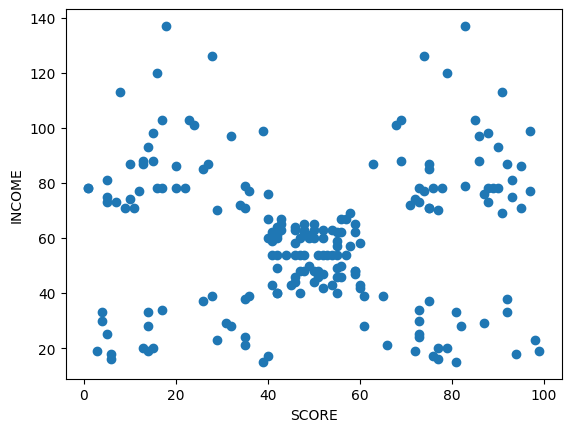

In [85]:
plt.scatter(df.score, df.income)
plt.xlabel('SCORE')
plt.ylabel('INCOME')
plt.show()

In [86]:
# https://prnt.sc/K9UUIaqJEf2G

In [87]:
from sklearn.cluster import KMeans
km1 = KMeans() #default cluster = 8

In [88]:
km1.fit_predict(df[['income', 'score']])

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 1, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1, 3, 1, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 2, 0, 6, 0, 2, 0, 2, 0,
       6, 0, 2, 0, 2, 0, 2, 0, 2, 0, 6, 0, 2, 0, 6, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7, 5, 7,
       5, 7], dtype=int32)

In [89]:
df.head()

,age,income,score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [90]:
df['km1_cluster'] = km1.fit_predict(df[['income', 'score']])
df.head()

,age,income,score,km1_cluster
0,19,15,39,4
1,21,15,81,3
2,20,16,6,4
3,23,16,77,3
4,31,17,40,4


In [91]:
km1.predict([[20, 37]])

array([4], dtype=int32)

In [92]:
km1.cluster_centers_

array([[ 62.73469388,  46.91836735],
       [ 89.40625   ,  15.59375   ],
       [ 82.38888889,  90.44444444],
       [ 24.95      ,  81.        ],
       [ 25.14285714,  19.52380952],
       [114.71428571,  78.42857143],
       [ 45.51282051,  51.51282051],
       [ 77.78571429,  73.28571429]])

In [93]:
df8 = df[df.km1_cluster==7]

In [94]:
df8

,age,income,score,km1_cluster
125,31,70,77,7
129,38,71,75,7
131,39,71,75,7
133,31,72,71,7
137,32,73,73,7
139,35,74,72,7
147,32,77,74,7
153,38,78,76,7
157,30,78,78,7
159,30,78,73,7


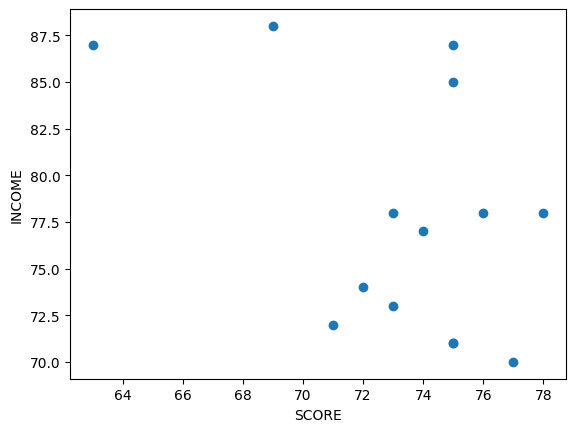

In [95]:
plt.scatter(df8.score, df8.income)
plt.xlabel('SCORE')
plt.ylabel('INCOME')
plt.show()

In [96]:
df1 = df[df.km1_cluster==0]
df2 = df[df.km1_cluster==1]
df3 = df[df.km1_cluster==2]
df4 = df[df.km1_cluster==3]
df5 = df[df.km1_cluster==4]
df6 = df[df.km1_cluster==5]
df7 = df[df.km1_cluster==6]

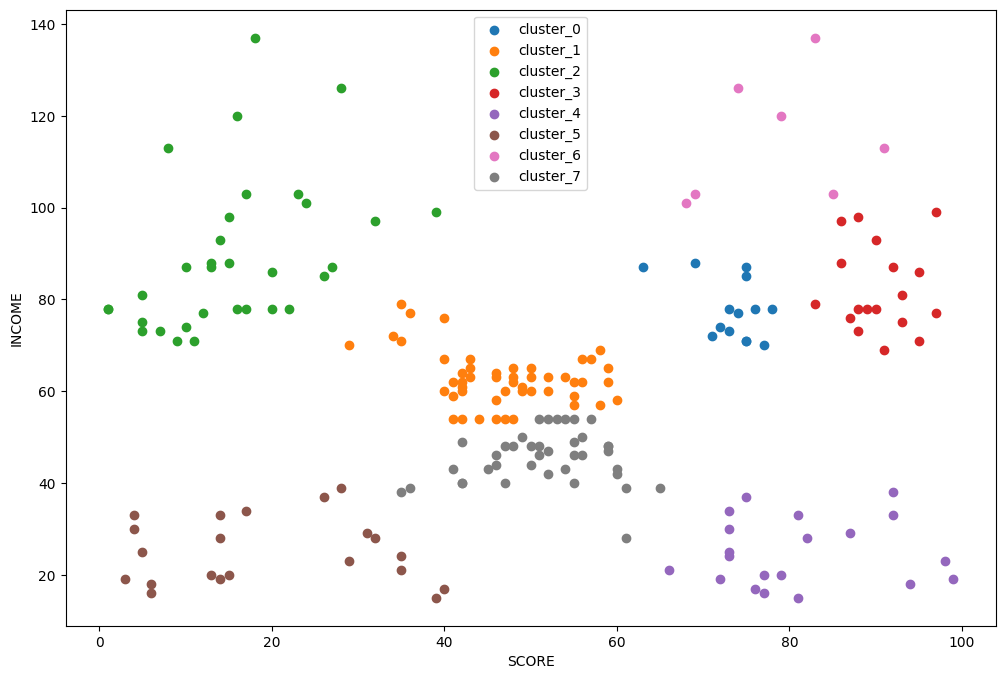

In [97]:
plt.figure(figsize=(12,8))

plt.scatter(df8.score, df8.income, label='cluster_0')
plt.scatter(df1.score, df1.income, label='cluster_1')
plt.scatter(df2.score, df2.income,  label='cluster_2')
plt.scatter(df3.score, df3.income, label='cluster_3')
plt.scatter(df4.score, df4.income, label='cluster_4')
plt.scatter(df5.score, df5.income, label='cluster_5')
plt.scatter(df6.score, df6.income, label='cluster_6')
plt.scatter(df7.score, df7.income, label='cluster_7')

plt.legend()
plt.xlabel('SCORE')
plt.ylabel('INCOME')
plt.show()

<Axes: xlabel='score', ylabel='income'>

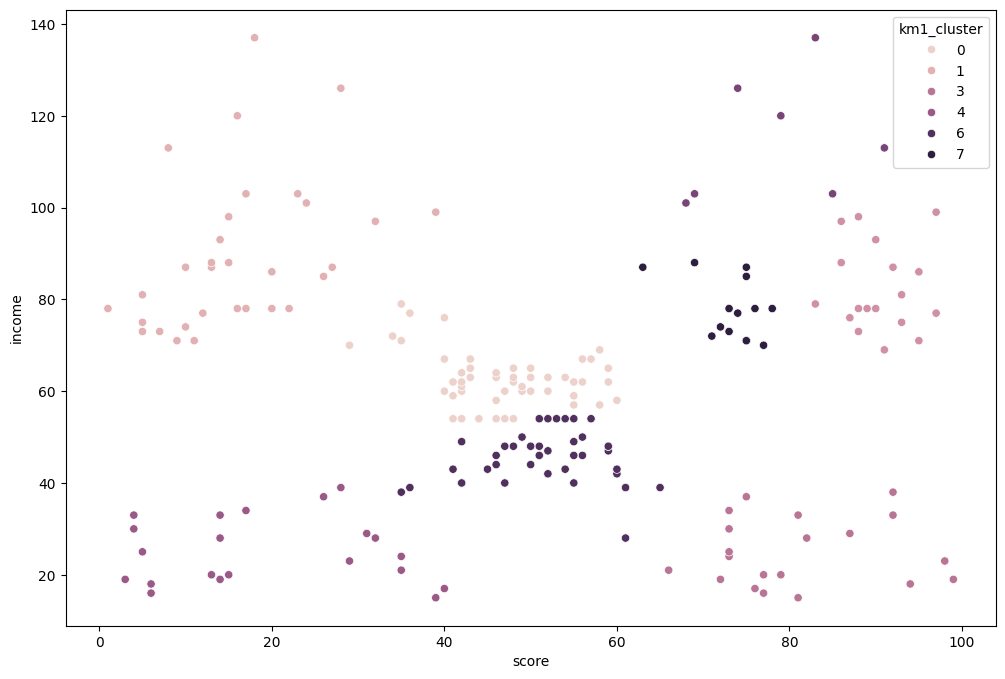

In [98]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='score', y='income', hue='km1_cluster' )

In [99]:
wcss = []

for i in range(1,15):
    km2 = KMeans(n_clusters=i)
    km2.fit(df[['income', 'score']])
    wcss.append(km2.inertia_)

In [100]:
wcss

[269981.28000000014,
 184609.98434090626,
 106348.37306211119,
 73679.78903948837,
 44448.45544793369,
 38797.9027638142,
 30259.657207285458,
 27417.992815536854,
 27212.66167166167,
 21321.464249108732,
 18531.790575634466,
 16245.959082029085,
 14531.914546727781,
 14457.592831188402]

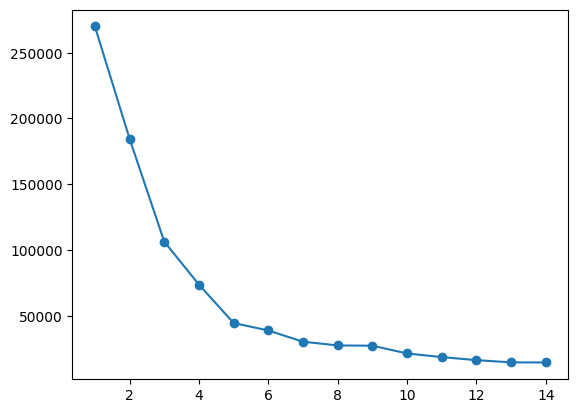

In [101]:
plt.plot(range(1,15), wcss, marker='o')

In [102]:
!pip install kneed

In [103]:
from kneed import KneeLocator

In [104]:
kne = KneeLocator(range(1,15), wcss, curve='convex', direction='decreasing')

In [105]:
kne

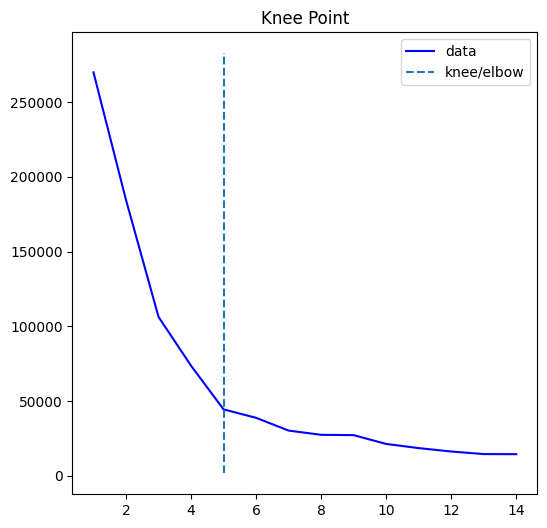

In [106]:
kne.plot_knee()

In [107]:
kne.knee

np.int64(5)

In [108]:
km3 = KMeans(n_clusters=5)

In [109]:
df['km1_cluster'] = km3.fit_predict(df[['income', 'score']])
df.head()

,age,income,score,km1_cluster
0,19,15,39,4
1,21,15,81,2
2,20,16,6,4
3,23,16,77,2
4,31,17,40,4


In [110]:
km3.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

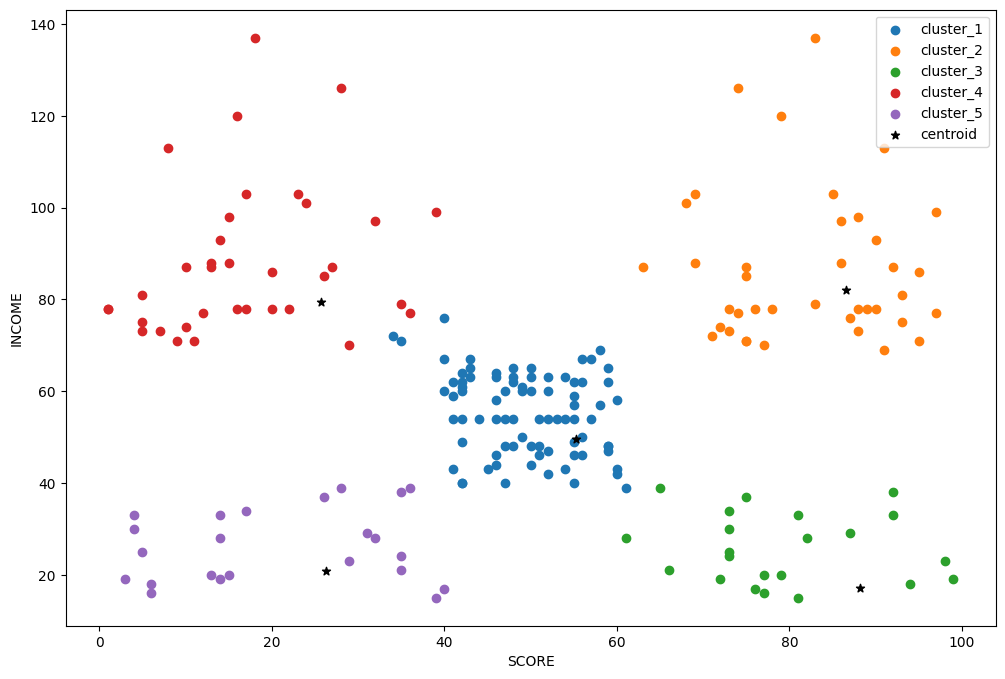

In [111]:
df1 = df[df.km1_cluster==0]
df2 = df[df.km1_cluster==1]
df3 = df[df.km1_cluster==2]
df4 = df[df.km1_cluster==3]
df5 = df[df.km1_cluster==4]

plt.figure(figsize=(12,8))

plt.scatter(df1.score, df1.income, label='cluster_1')
plt.scatter(df2.score, df2.income,  label='cluster_2')
plt.scatter(df3.score, df3.income, label='cluster_3')
plt.scatter(df4.score, df4.income, label='cluster_4')
plt.scatter(df5.score, df5.income, label='cluster_5')

plt.scatter(km3.cluster_centers_[:,0], km3.cluster_centers_[:,1], label='centroid', color='black', marker='*')

plt.legend()
plt.xlabel('SCORE')
plt.ylabel('INCOME')
plt.show()

In [112]:
df.head()

,age,income,score,km1_cluster
0,19,15,39,4
1,21,15,81,2
2,20,16,6,4
3,23,16,77,2
4,31,17,40,4


In [113]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'url', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', '_i13', 'df', '_i14', '_14', '_i15', '_i16', '_16', '_i17', '_i18', '_18', '_i19', '_19', '_i20', '_i21', 'sns', 'plt', 'wr', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', 'KMeans', 'km1', '_i29', '_29', '_i30', '_30', '_i31', '_31', '_i32', '_32', '_i33', '_33', '_i34', '_34', '_i35', 'df8', '_i36', '_36', '_i37', '_i38', 'df1', 'df2', 'df3', 'df4', 'df5', 'df6', 'df7', '_i39', '_i40', '_40', '_i41', 'wcss', 'i', 'km2', '_i42', '_42', '_i43', '_43', '_i44', '_i45', '_i46', '_i47', '_exit_code', '_i48', 'KneeLocator', '_i49', 'kne', '_i50', '_50', '_i51', '_i52', '_52', '_i53', 'km3', '_i54', '_54', '_i55', '_55', '_i56', '_i57', 'joblib', '_i58', '_i59', '_i60', '_i61', 

In [114]:
print(type(kmeans))

<class 'sklearn.cluster._kmeans.KMeans'>


In [115]:
import pickle

with open("220128.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model Saved Successfully")

Model Saved Successfully


In [116]:
from google.colab import files

files.download("220128.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>